# Synthetic Gaussian-Beam Focusing Through Disordered SHU Cavities

**Goal.** Quantify how well a focused beam can be transmitted/focused through a disordered *stealthy hyperuniform* (SHU) slab placed inside a 3D cavity, and how the cavity **air gap** affects that focusing — compared against a purely 2D experiment.

**Key idea — superposition instead of a real beam source.**
Maxwell's equations are linear, so we never actually simulate a Gaussian beam hitting the slab. Instead we run one FDTD simulation *per point-dipole emitter* placed at transverse positions $x = \pm0.5, \pm1.5, \dots, \pm5.5$, and record the transmitted field $E_z(x, \nu)$ on a line behind the slab. Any input beam is then a **weighted coherent sum** of these single-emitter responses:

$$E_z^{\text{beam}}(x,\nu) \;=\; \sum_{j} w_j(\nu)\, E_z^{(j)}(x,\nu)$$

where the complex weights $w_j(\nu)$ encode the amplitude **and phase** that a converging Gaussian beam would have at each emitter location. This lets us synthesize *any* beam (here, a beam focused at a chosen distance) in post-processing from a single reusable set of simulations.

**Pipeline.**
1. **Load** the per-emitter FDTD results for each dataset (2D experiment + 3D cavities with different air gaps).
2. **Build the beam weights** $w_j(\nu)$ from the Gaussian-beam amplitude/phase profile.
3. **Coherently superpose** the emitter fields → synthesized transmitted beam (through slab) and reference (empty cavity).
4. **Quantify focusing** of the exit-line intensity $|E_z|^2$ vs. frequency via the participation ratio (PR) and the beam width $\sigma$.
5. **Visualize & compare** across air gaps.

In [1]:
import scipy.io as sio
from dataclasses import dataclass
from typing import List, Tuple
import os
from dotenv import load_dotenv
load_dotenv()
import tidy3d as td
from tidy3d import web
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from natsort import natsorted
import matplotlib
import matplotlib.colors as mcolors
import h5py
import plotly.graph_objs as go
import plotly
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import display, HTML
plotly.offline.init_notebook_mode()
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))
import pandas as pd
import sys
import os
import re

# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(rf'../../../../tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

# Consistent plot style (matches 20251211_Phase_Diagrams_L_sweep)
plt.rc('font', family='Arial', size=12)

In [2]:
tidy3dAPI = os.environ["API_TIDY3D_KEY"]


## Step 1 — Load the per-emitter FDTD field data

Each path below is one **dataset**: the 2D reference experiment, plus a series of **3D cavities** that differ only in their **air gap** (0 mm → 1 mm). Inside each folder there is one result file per emitter, whose transverse position is parsed from the filename (`emmiter_<x>`).

For every emitter we load two simulations via `AM.loadFromFile`:
- `sim_data` — field **with the SHU slab** in the cavity.
- `sim_data0` — the **empty-cavity reference** (same run, no slab).

We convert monitor frequencies to GHz and pull the complex $E_z$ field on **two transverse cut-lines** (both restricted to $|x|\le 50$):
- `field_slab_cavity` — the line just **behind the slab** ($y \le 10$): the transmitted/exit field.
- `field_empty_cavity` — the reference line in the empty cavity ($y \le -5.5555$): the incident "beam at entry".

Everything is stored in the nested dict `data_field_intensities[dataset][emitter_x]`, keyed so we can later sum over emitters for each dataset and frequency.

In [3]:
data_field_intensities = AM.read_hdf5_as_dict("./data/cavity_data/0mm_Gap_Cavity_3D_field_intensities.h5")

In [4]:
a=1.5873
data_field_intensities["20250721 0mm Gap Cavity 3D"]["-0.5"]["line_x"]

array([-49.9248927 , -49.80686695, -49.6888412 , -49.57081545,
       -49.4527897 , -49.33476395, -49.2167382 , -49.09871245,
       -48.9806867 , -48.86266094, -48.74463519, -48.62660944,
       -48.50858369, -48.39055794, -48.27253219, -48.15450644,
       -48.03648069, -47.91845494, -47.80042918, -47.68240343,
       -47.56437768, -47.44635193, -47.32832618, -47.21030043,
       -47.09227468, -46.97424893, -46.85622318, -46.73819742,
       -46.62017167, -46.50214592, -46.38412017, -46.26609442,
       -46.14806867, -46.03004292, -45.91201717, -45.79399142,
       -45.67596567, -45.55793991, -45.43991416, -45.32188841,
       -45.20386266, -45.08583691, -44.96781116, -44.84978541,
       -44.73175966, -44.61373391, -44.49570815, -44.3776824 ,
       -44.25965665, -44.1416309 , -44.02360515, -43.9055794 ,
       -43.78755365, -43.6695279 , -43.55150215, -43.43347639,
       -43.31545064, -43.19742489, -43.07939914, -42.96137339,
       -42.84334764, -42.72532189, -42.60729614, -42.48

In [5]:
emitters = np.array([(x) for x in data_field_intensities[list(data_field_intensities.keys())[0]].keys()])
emitters

array(['-0.5', '-1.5', '-2.5', '-3.5', '-4.5', '-5.5', '0.5', '1.5',
       '2.5', '3.5', '4.5', '5.5'], dtype='<U4')

## Step 2 — Gaussian-beam weights $w_j(\nu)$

`calculate_gaussian(emitter, lambda_0, w_0, w_ap, z_focus)` returns the **complex weight** for the emitter at transverse position `emitter` — the amplitude **and** phase a converging beam would carry at that point, for wavelength `lambda_0`. Two amplitude mechanisms are combined:

$$w(x,\lambda) \;=\; \underbrace{\exp\!\left[-\tfrac{x^{2}}{w(z)^{2}}\right]}_{\text{waist envelope}}\;\underbrace{\exp\!\left[-\tfrac{x^{2}}{w_{\mathrm{ap}}^{2}}\right]}_{\text{aperture taper}}\;\underbrace{\exp\!\left[-\, i\,k\,\tfrac{x^{2}}{2R(z)}\right]}_{\text{converging phase}}, \qquad k=\tfrac{2\pi}{\lambda}.$$

with the standard Gaussian-beam relations at the focus distance $z=z_{\mathrm{focus}}$:
- Rayleigh range $\;z_R = \pi w_0^2/\lambda$
- wavefront radius $\;R(z) = z\big[1+(z_R/z)^2\big]$
- beam radius at the emitter plane $\;w(z) = w_0\sqrt{1+(z/z_R)^2}$

- **Mechanism 1 — waist ($w_0=2$ mm).** The physical Gaussian envelope propagated from the waist *at the focus*, and the wavefront radius $R(z)$ that sets the **converging** quadratic phase. Because $\lambda\gg$ aperture here, the emitters sit deep in the far field ($z\gg z_R$), so this envelope is ≈ flat — but it still fixes $R(z)$.
- **Mechanism 2 — aperture ($w_{\mathrm{ap}}=5$ mm).** An explicit Gaussian taper *at the emitter plane*, which is what actually rolls off the outer emitters (|w| ≈ 0.99 at $x=0.5$ → 0.30 at $x=5.5$).
- **Phase.** Converging quadratic; the **negative** sign ($e^{-i\omega t}$ convention) is empirically the one that focuses — it gives the narrowest pre-slab spot ($\sigma_{6\,\mathrm{GHz}}=4.98$ mm vs 5.25 mm for $+$, 5.11 mm aperture-only).

> **Focus lands on the pre-slab plane.** From the source notebook *20250708 Numerical Experiment Cavity 3D*, the dipoles are placed at $y=-(\text{slab half-length})-22.5$, i.e. **exactly 22.5 mm in front of the slab entrance** (independent of $a$). The pre-slab reference line is at $y=-5.5555\approx$ that entrance, so $z_{\mathrm{focus}}=22.5$ mm focuses the synthesized beam **on the pre-slab plane** — the "Beam at Entry" panel. The exit line ($y=+10$) is 15.56 mm further downstream.

> **Units.** Geometry is in **mm** and `freqs` are in **GHz**, so the calling cell builds `lambdas` with $c=$ `td.C_0/1e12` $=299.79$ mm·GHz. (Using `td.C_0` directly — µm·Hz — gives $\lambda\sim10^{13}$ and collapses every weight to $1+0j$, i.e. no shaping at all.)
>
> **Physical caveat.** Aperture $D\approx11$ mm $<\lambda=33$–$88$ mm, so this microwave geometry is far from the focusing regime ($\lambda\gg D$, NA ≈ 0.24). The converging phase across the aperture is only a few degrees, so even focused at the pre-slab plane the beam narrows only modestly (~2.5%) — the synthesis reveals a *trend*, not a diffraction-limited spot.

The cell below lists the emitter positions used as summation points.

In [6]:
def calculate_gaussian(emitter, lambda_0, w_0=2.0, w_ap=5.5, z_focus=22.5):
    """Complex weight for the emitter at transverse position `emitter`, for a
    beam converging to an on-axis focus a distance `z_focus` downstream.

    Two amplitude mechanisms are combined multiplicatively:
      1. the physical Gaussian-beam envelope propagated from the focal waist
         `w_0` (via the Rayleigh range / wavefront radius R), and
      2. an explicit Gaussian aperture `w_ap` imposed at the emitter plane.

    All lengths are in the SAME units as the geometry (mm):
      lambda_0 : wavelength in mm (see the units note in the calling cell).
      w_0      : beam waist AT THE FOCUS (mm). Sets the physical envelope and
                 the wavefront curvature R at the emitter plane. For this
                 geometry (lambda >> aperture) the emitters sit deep in the far
                 field, so this envelope is ~flat -- but it still sets R.
      w_ap     : 1/e amplitude half-width of the aperture AT THE EMITTER PLANE
                 (mm). This is what actually tapers the outer emitters
                 (|w|: 0.99 at x=0.5 -> 0.30 at x=5.5 for w_ap=5).
      z_focus  : emitter-plane -> focus distance (mm). The dipoles were placed
                 at y = -(slab_half_length) - 22.5 (see the source notebook
                 "20250708 Numerical Experiment Cavity 3D"), i.e. exactly
                 22.5 mm in front of the slab entrance. The pre-slab reference
                 line sits at y = -5.5555 ~ that entrance, so z_focus = 22.5
                 focuses the beam ON THE PRE-SLAB PLANE (the "Beam at Entry"
                 line). The exit line (y = +10) is 15.56 mm further downstream.
    """
    # --- Mechanism 1: physical Gaussian-beam propagation from the focal waist ---
    z_r = np.pi * w_0**2 / lambda_0             # Rayleigh range
    R   = z_focus * (1 + (z_r / z_focus)**2)    # wavefront radius at the emitter plane
    w_z = w_0 * np.sqrt(1 + (z_focus / z_r)**2) # Gaussian beam radius at the emitter plane
    envelope = np.exp(-(emitter)**2 / w_z**2)   # far-field Gaussian envelope (~1 here)

    # --- Mechanism 2: explicit aperture taper at the emitter plane ---
    aperture = np.exp(-(emitter)**2 / w_ap**2)  # real roll-off across the emitters

    amplitude = envelope * aperture

    # Converging quadratic phase, using the waist-derived wavefront radius R:
    # pre-compensate the extra path from an off-axis emitter to the on-axis
    # focus so all emitters add in phase there. The NEGATIVE sign (converging,
    # e^{-i w t} convention) is empirically confirmed on the data: it gives the
    # narrowest pre-slab spot (sigma@6GHz = 4.98 mm vs 5.25 mm for +, 5.11 mm
    # for aperture-only). Flip only if your field convention is e^{+i w t}.
    k = 2 * np.pi / lambda_0
    phase = -k * (emitter)**2 / (2 * R)
    return amplitude * np.exp(1j * phase)


In [7]:
from matplotlib.colors import LogNorm

def plot_line_intensity(data,freqs_list,lines_x,titles:any=None, log:bool=True):
    colors = [
                  (1, 1, 1),  # White
                  (0, 0, 1),  # Blue
                  (1, 1, 0),  # Yellow
                  (0, 1, 0),  # Green
                  (1, 0, 0), #Red
                  (0, 0, 0), # Black
                  ]  
        
        # Create a custom colormap
    n_bins = 500  # Number of bins for smooth transition
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_colormap", colors, N=n_bins)
    nrows = int(len(data)/2)
    fig, ax = plt.subplots(nrows,2,figsize=(14,4*nrows), dpi=300, constrained_layout=True)

    log_label = r"$\log|E|^2$" if log else r"$|E|^2$"
    for i, axi in enumerate(ax.flat):
            intensity = np.abs(data[i])**2
            # intensity[intensity/np.max(intensity)<=1e-4]=0
            value = (intensity)/np.max(intensity)
            # value[np.isnan(value)]=0
            if log:
                im=axi.imshow(value, 
                        extent =[np.min(freqs_list[i]),np.max(freqs_list[i]),np.min(lines_x[i]),np.max(lines_x[i])], 
                           origin ='lower', cmap=cmap,aspect='auto',norm=LogNorm(vmin=np.min(value), vmax=np.max(value)))
            else: 
                im=axi.imshow(value, 
                        extent =[np.min(freqs_list[i]),np.max(freqs_list[i]),np.min(lines_x[i]),np.max(lines_x[i])], 
                           origin ='lower', cmap=cmap,aspect='auto',vmin=np.min(value), vmax=np.max(value))

            cbar = fig.colorbar(im, ax=axi, orientation='vertical', pad=0.03, location="right", shrink=0.6)
            cbar.ax.text(0.9, 1.1, log_label, va='center', ha='left', transform=cbar.ax.transAxes)

            axi.set_xlabel(rf"$\nu$ (GHz)")
            axi.set_ylabel(rf"$x$")
            axi.tick_params(axis='both', which='major')
            if titles:
                axi.set_title(titles[i])
       
    plt.show()


## Step 3 — Coherent superposition (synthesize the focused beam)

For each dataset we build the transmitted focused beam by summing every emitter's recorded field, weighted by its Gaussian-beam coefficient, at each frequency:

$$E_z^{\text{beam}}(x,\nu) = \sum_{j} E_z^{(j)}(x,\nu)\, w\big(x_j,\lambda(\nu)\big)$$

- `beam_shaped` — superposition of the **slab** fields → the beam transmitted **through the SHU cavity**.
- `beam_shaped_ref` — the same superposition of the **empty-cavity** fields → the **reference beam at entry** (no disorder), appended at the end as `"Beam At Entry"`.

The sum is complex (amplitude *and* phase preserved), so interference between emitters is what produces — or destroys — the focus. The result is one synthesized exit-line field per dataset, stored in `lines`, with matching `freqs_list` and transverse coordinates `lines_x`.

In [8]:
title_list = ["Field Intensity at Exit","Beam Focusing at Entry"]
lines = []
freqs_list = []
lines_x = []
for n,simulation in enumerate(data_field_intensities.keys()):
    beam_shaped_ref = np.zeros(shape=np.shape(data_field_intensities[simulation][(emitters[0])]["field_empty_cavity"]),dtype=np.complex128)
    beam_shaped = np.zeros(shape=np.shape(data_field_intensities[simulation][emitters[0]]["field_empty_cavity"]),dtype=np.complex128)
    for i,item in enumerate(emitters):
        data_ref = data_field_intensities[simulation][item]["field_empty_cavity"]
        data = data_field_intensities[simulation][item]["field_slab_cavity"]
        # freqs are stored in GHz and the geometry is in mm, so the wavelength
        # must use c in mm*GHz (= td.C_0/1e12 = 299.79...). Using td.C_0 (um*Hz)
        # directly gives lambda ~ 1e13 and collapses every weight to 1+0j.
        lambdas = (td.C_0/1e12)/np.array(data_field_intensities[simulation][item]["freqs"])

        beam_shaped_ref += data_ref*np.array([calculate_gaussian(float(item),lambda_0) for lambda_0 in lambdas])
        beam_shaped += data*np.array([calculate_gaussian(float(item),lambda_0) for lambda_0 in lambdas])   
    line_exit = beam_shaped.squeeze()
    line_ref = beam_shaped_ref.squeeze() 
    lines.append(line_exit)
    freqs_list.append(data_field_intensities[simulation][item]["freqs"])
    lines_x.append(data_field_intensities[simulation][item]["line_x"])
    # titles=[f"A - {title_list[n]}","B - Beam at entry"]

lines.append(line_ref)
freqs_list.append(data_field_intensities[simulation][item]["freqs"])
lines_x.append(data_field_intensities[simulation][item]["line_x"])


## Step 4 — Quantify the focusing

Two scalar metrics summarize how tightly the exit intensity $I(x) = |E_z^{\text{beam}}(x)|^2$ is concentrated, computed **per frequency**:

- **Participation ratio** `calculate_PR` — an effective spot size,
$$\text{PR} = \frac{\left(\int I\,dx\right)^{2}}{\int I^{2}\,dx}.$$
Small PR ⇒ energy concentrated in a narrow spot (good focusing); large PR ⇒ spread out.

- **Beam width** `calculate_sigma` — the standard deviation of the normalized intensity profile,
$$\sigma = \sqrt{\langle x^2\rangle - \langle x\rangle^2}, \qquad \langle f\rangle = \frac{\int f\,I\,dx}{\int I\,dx}.$$

Both are integrated over the transverse line with `scipy.integrate.trapezoid`. Sweeping frequency turns each into a spectrum PR($\nu$) / $\sigma(\nu)$, revealing which frequencies focus best through each cavity.

In [9]:
#Calculate PR 
import scipy.integrate
from scipy.signal import savgol_filter

def smooth_curve(y, window=15, poly=3):
    """Savitzky-Golay smoothing of a 1D spectrum along frequency.

    Applied independently to each contiguous run of finite values, so NaN/inf
    gaps (e.g. frequencies where the thresholded beam is all-zero -> PR = 0/0)
    are preserved as line breaks rather than bridged over.

    window : filter length in samples (forced odd, clipped per segment).
             None or <3 returns the curve unchanged. Larger = smoother.
    poly   : polynomial order (kept < window). Order 2-3 preserves the gap dip
             and band-edge shape while removing the fast speckle fluctuation.
    """
    y = np.asarray(y, dtype=float)
    if window is None or window < 3 or y.size < 3:
        return y
    out = np.full(y.size, np.nan)
    idx = np.flatnonzero(np.isfinite(y))
    if idx.size == 0:
        return y
    for run in np.split(idx, np.flatnonzero(np.diff(idx) > 1) + 1):
        seg = y[run]
        w = int(window) | 1                              # force odd
        if w >= seg.size:
            w = seg.size - 1 if seg.size % 2 == 0 else seg.size - 2
        out[run] = seg if w < 3 else savgol_filter(seg, w, min(poly, w - 1))
    return out


def calculate_PR(intensity_array,x1:any=10):
    values = intensity_array
    integral_1 = scipy.integrate.trapezoid(values**2, x=x1, axis=0)
    integral_2 = scipy.integrate.trapezoid(values, x=x1,axis=0)**2

    return integral_2/integral_1
def calculate_sigma(intensity_array, x1):
    x1 = np.asarray(x1)
    values = intensity_array

    # Reshape x1 to broadcast over columns (axis=1)
    x1 = x1[:, np.newaxis]  

    norm = scipy.integrate.trapezoid(values, x=x1[:, 0], axis=0)
    mean = scipy.integrate.trapezoid(values * x1, x=x1[:, 0], axis=0) / norm
    mean_sq = scipy.integrate.trapezoid(values * x1**2, x=x1[:, 0], axis=0) / norm
    sigma = np.sqrt(mean_sq - mean**2)
    return sigma


def transmission_spectrum(dataset_dict, a=15.9, c_mm_per_ns=299.792458, core_x=None):
    """Incoherent transmission spectrum vs reduced frequency a/lambda for one dataset.

        T(nu) = sum_emitters  int |E_slab_exit|^2 dx  /  sum_emitters int |E_empty_entry|^2 dx

    This is the clean, mode-averaged transmission (the coherent-beam ratio would
    be biased by the aperture weighting). The deep dip locates the photonic gap.

    core_x : if given, integrate only over |x| <= core_x (same units as line_x).
             Excludes the transverse domain-boundary background that otherwise
             fills the gap floor (~-40 dB -> the true ~-56 dB tunneling floor).

    Returns (u, T) with u = a/lambda = a*f/c  (dimensionless, scale-invariant).
    """
    ems = list(dataset_dict.keys())
    f = np.asarray(dataset_dict[ems[0]]["freqs"]).squeeze()
    xln = np.asarray(dataset_dict[ems[0]]["line_x"]).squeeze()
    keep = np.abs(xln) <= core_x if core_x is not None else np.ones_like(xln, dtype=bool)
    num = np.zeros_like(f, dtype=float)
    den = np.zeros_like(f, dtype=float)
    for e in ems:
        Es = np.abs(np.asarray(dataset_dict[e]["field_slab_cavity"]))**2
        Ee = np.abs(np.asarray(dataset_dict[e]["field_empty_cavity"]))**2
        num += scipy.integrate.trapezoid(Es[keep, :], x=xln[keep], axis=0)
        den += scipy.integrate.trapezoid(Ee[keep, :], x=xln[keep], axis=0)
    u = a * f / c_mm_per_ns
    return u, num / den


def plot_PR(data, freqs_list, titles: any = None, calculation_method="PR", a=15.9,
            show_transmission=True, gap_edges=(0.333584, 0.399156), data_dict=None,
            core_x=None, smooth=17):
    """PR(nu) / sigma(nu) spectra, overlaid with the transmission spectrum and the
    photonic band-gap shading.

    gap_edges : band-gap edges in a/lambda. These are the RAW MPB reduced
        frequencies (higher gap) -- MPB already outputs a/lambda, which is
        scale-invariant, so they are used directly. Do NOT multiply by
        a_um/a_mpb (=15.9/14.07): that double-divides by the lattice constant and
        pushes the gap ~13% too high ([0.377,0.451]). The FDTD transmission
        confirms the gap sits at ~[0.313,0.391] in these same a/lambda units.
    show_transmission : overlay T(a/lambda) [dB] on a right-hand axis, computed
        per dataset from the global `data_field_intensities` (or `data_dict`).
    core_x : optional transverse window |x|<=core_x for the transmission integral
        (excludes the domain-edge background; deepens the apparent gap floor).
    smooth : Savitzky-Golay window (samples) applied to each PR/sigma curve; the
        raw curve is drawn faintly underneath. None or <3 disables smoothing.
    """
    c_mm_per_ns = 299.792458          # = c in mm/ns = mm·GHz
    if data_dict is None:
        data_dict = globals().get("data_field_intensities", None)
    dsets = list(data_dict.keys()) if data_dict is not None else []

    fig, ax = plt.subplots(figsize=(4.6, 2.7), dpi=300)
    axT = ax.twinx() if show_transmission else None

    if calculation_method == "PR":
        ylabel = r"PR($\nu$) [mm]"
    else:
        ylabel = r"$\sigma(\nu)$ [mm]"

    # --- band-gap shading (behind everything) ---
    if gap_edges is not None:
        ax.axvspan(gap_edges[0], gap_edges[1], color="0.80", alpha=0.6, lw=0,
                   zorder=0, label="band gap")

    for i in range(len(data)):
        try:
            intensity = np.abs(data[i])**2
            value = (intensity) / np.max(intensity)
            if calculation_method == "PR":
                length_value = calculate_PR(value, lines_x[i])
            else:
                length_value = calculate_sigma(value, lines_x[i])
            u = a * np.asarray(freqs_list[i]) / c_mm_per_ns
            line, = ax.plot(u, smooth_curve(length_value, smooth), linewidth=1.5,
                            zorder=3, label=titles[i] if titles else None)
            if smooth and smooth >= 3:                       # faint raw curve underneath
                ax.plot(u, length_value, lw=0.5, alpha=0.20, zorder=2,
                        color=line.get_color())

            # --- transmission overlay for the real datasets (not the entry beam) ---
            if show_transmission and i < len(dsets):
                uT, T = transmission_spectrum(data_dict[dsets[i]], a=a,
                                              c_mm_per_ns=c_mm_per_ns, core_x=core_x)
                axT.plot(uT, 10 * np.log10(T + 1e-30), linewidth=1.0, ls="--",
                         color=line.get_color(), alpha=0.9, zorder=2)
        except Exception:
            pass

    ax.set_ylabel(ylabel)
    ax.set_xlabel(r"$\nu\ (a/\lambda)$")
    ax.tick_params(axis="both", which="major")
    ax.set_ylim(0, 50)
    ax.set_xlim(a / (c_mm_per_ns / 6), a / (c_mm_per_ns / 9))
    ax.set_zorder(1); ax.patch.set_visible(False)  # keep PR lines above the twin axis

    if axT is not None:
        axT.set_ylabel("Transmission [dB]")
        axT.set_ylim(-45, 3)
        # dashed grey proxy so the legend explains the transmission curves
        axT.plot([], [], ls="--", color="0.4", label="transmission")

    # combined legend (PR curves + gap patch + transmission proxy)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = (axT.get_legend_handles_labels() if axT is not None else ([], []))
    ax.legend(h1 + h2, l1 + l2, fontsize=6, loc="upper right", framealpha=0.9)
    plt.tight_layout()
    plt.show()


In [10]:
# --- Normalized DOS from the MPB band statistics (Luis Analysis folder) -------
NDOS_FILE = "./Luis Data/Cavity_Like_Structures_h5/eps_50_bands/chi_0.37_band_sampling.h5"


def nDOS_from_band_sampling(file=NDOS_FILE, n_bins=400, first_terms=20, truncate=0.98):
    """Normalized density of states nDOS(nu) from the MPB band sampling.

    Reproduces `Luis Analysis/Computing_nDOS.ipynb`: pool every eigenfrequency in
    `all_bands` (shape Nbands x Nk x Nsamples, already in reduced units
    nu = a/lambda), histogram it, divide by Nsamples, and normalize by the LINEAR
    low-frequency DOS -- a straight-line fit to the first `first_terms` bins,
    where the 2D DOS is Debye-like (~ nu). So nDOS ~ 1 means "as many modes as
    free space" and nDOS = 0 marks the photonic band gap.

    eps=50 (chi=0.37) is the default: its gap [0.3193, 0.3894] is the one that
    matches the transmission dip of this experiment -- the other epsilons in
    `PBG_boundaries.ipynb` (43/45/47) put the gap 1-8 % higher.

    truncate : MPB solved a finite number of bands (800 here), so the spectrum is
        complete only up to nu_c = min_{k,sample} band[-1] (0.4517 for eps=50),
        and the topmost bands crowd together right below it -- the last ~2 % of
        the range carries a spurious nDOS spike (up to ~9, same shape for every
        eps: near-degenerate, poorly converged top eigenvalues). Keep only
        nu <= truncate * nu_c. Set to None to see the raw tail.

    Returns (centers, nDOS), 1D arrays of length <= `n_bins`.
    """
    with h5py.File(file, "r") as f:
        bands = f["all_bands"][()]
        nsamples = int(f["Nsamples"][()])
    hist, edges = np.histogram(bands, bins=n_bins)
    hist = hist / nsamples
    centers = 0.5 * (edges[:-1] + edges[1:])
    coef = np.polyfit(centers[:first_terms], hist[:first_terms], deg=1)
    ndos = hist / (centers * coef[0] + coef[1])
    if truncate:
        keep = centers <= truncate * bands[-1].min()
        centers, ndos = centers[keep], ndos[keep]
    return centers, ndos


In [ ]:
def plot_gap_diagnostic(lines, freqs_list, lines_x, dataset_index=0, data_dict=None,
                        gaps=((0.162002, 0.267659), (0.333584, 0.399156)), logplot=False, threshold=1e-3,
                        a=15.9, c_mm_per_ns=299.792458, core_x=None,
                        xlim=None, ymap=(-50, 50), title=None, smooth=15,
                        ndos_file=NDOS_FILE, ndos_bins=400, ndos_ylim=(0, 6)):
    """2x2 panel figure, every panel against the reduced frequency nu = a/lambda:

        (a) Transmission (log scale) -- T(nu) = Sum int|E_slab|^2 / Sum int|E_empty|^2
        (b) Intensity map            -- |E_z^beam|^2(x, nu) of the coherent exit beam
                                        (log color scale, colorbar on top)
        (c) PR(nu) [mm]              -- participation ratio of the exit beam (+ entry ref)
        (d) nDOS(nu)                 -- normalized density of states from the MPB band
                                        statistics (eps=50, chi=0.37; see the Luis
                                        Analysis folder). Vanishes across the gap.

    `gaps` : list of (lower, upper) band-gap intervals in a/lambda (raw MPB, NOT
    rescaled). Both gaps of this structure are shaded on every panel
    (translucent on the map, so the data shows through).
    xlim=None shows the whole available range. core_x: optional |x|<=core_x window
    for the transmission integral (drops the transverse domain-edge background).
    smooth : Savitzky-Golay window (samples) applied to the PR curves; the raw PR
        is drawn faintly underneath. None or <3 disables smoothing.
    ndos_file : band-sampling .h5 for panel (d); None (or a missing file) leaves
        that panel out and the figure keeps only (a)-(c).
    ndos_bins : histogram bins for the nDOS (200-400 is the usable range: fewer
        washes out the band edges, more makes the sampling noise dominate).
    """
    if data_dict is None:
        data_dict = globals().get("data_field_intensities", None)
    dsets = list(data_dict.keys())
    key = dsets[dataset_index]

    u_map = a * np.asarray(freqs_list[dataset_index]).squeeze() / c_mm_per_ns
    x = np.asarray(lines_x[dataset_index]).squeeze()
    I = np.abs(lines[dataset_index])**2
    I[I / np.max(I, axis=0) <= threshold] = 1e-15  # threshold to avoid log(0) in the color map
    I = I / (np.max(I, axis=0))

    # nDOS for panel (d) -- optional, so an out-of-sync data folder can't break the figure
    ndos = None
    if ndos_file is not None:
        if os.path.exists(ndos_file):
            ndos = nDOS_from_band_sampling(ndos_file, n_bins=ndos_bins)
        else:
            print(f"nDOS file not found ({ndos_file}) -- skipping panel (d).")

    colors = [(1,1,1),(0,0,1),(1,1,0),(0,1,0),(1,0,0),(0,0,0)]
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_colormap", colors, N=500)

    fig, axes = plt.subplots(2, 2, figsize=(9.6, 6.2), dpi=200, sharex=True,
                             gridspec_kw=dict(hspace=0.30, wspace=0.28))
    ax = axes.ravel()   # (a) top-left, (b) top-right, (c) bottom-left, (d) bottom-right

    # (a) transmission -- LOG scale (not dB)
    uT, T = transmission_spectrum(data_dict[key], a=a, c_mm_per_ns=c_mm_per_ns, core_x=core_x)
    ax[0].plot(uT, np.maximum(T, 1e-12), color="k", lw=1.1)
    ax[0].set_yscale("log")
    ax[0].set_ylabel("Transmission"); ax[0].set_ylim(1e-5, 2)
    for lo, hi in gaps:
        ax[0].axvspan(lo, hi, color="gray", alpha=0.6, lw=0)

    # (b) intensity map (coherent exit beam) -- colorbar ON TOP
    if logplot:
        im = ax[1].imshow(I, extent=[u_map.min(), u_map.max(), x.min(), x.max()], origin="lower",
                      cmap=cmap, aspect="auto", norm=LogNorm(vmin=I.min(), vmax=I.max()))
    else: 
         im = ax[1].imshow(I, extent=[u_map.min(), u_map.max(), x.min(), x.max()], origin="lower",
                              cmap=cmap, aspect="auto", vmin=I.min(), vmax=I.max())
    for lo, hi in gaps:                     # same grey shading as the other panels,
        ax[1].axvspan(lo, hi, color="gray", alpha=0.7, lw=0, zorder=2)  # lighter so the map shows through
    ax[1].set_ylabel(r"X[cm]"); ax[1].set_ylim(*ymap)
    cb = fig.colorbar(im, ax=ax[1], orientation="horizontal", location="top",
                      fraction=0.06, pad=0.03)
    cb.ax.text(1.05, 0.5, r"$|E|^2$", va='center', ha='left', transform=cb.ax.transAxes)

    # (c) PR / IPR  (raw faint + Savitzky-Golay smoothed)
    I_E=np.abs(lines[dataset_index])**2 / np.max(np.abs(lines[dataset_index])**2)
    I_R=np.abs(lines[-1])**2 / np.max(np.abs(lines[-1])**2)
    prE = calculate_PR(I_E, x)
    prR = calculate_PR(I_R, np.asarray(lines_x[-1]).squeeze())
    uR = a * np.asarray(freqs_list[-1]).squeeze() / c_mm_per_ns
    # if smooth and smooth >= 3:
        # ax[2].plot(u_map, prE, color="C0", lw=0.5, alpha=0.20)   # raw exit PR underneath
    ax[2].plot(u_map, smooth_curve(prE, smooth), color="C0", lw=1.6, label="Exit beam")
    ax[2].plot(uR, smooth_curve(prR, smooth), color="C1", lw=1.2, label="Beam at entry")
    for k, (lo, hi) in enumerate(gaps, 1):
        ax[2].axvspan(lo, hi, color="gray", alpha=0.6, lw=0)
    ax[2].set_ylabel(r"$\xi(\nu)$ [cm]"); ax[2].set_ylim(0, 50)
    ax[2].legend(fontsize=6, loc="upper right")

    # (d) nDOS from the MPB band statistics -- independent of the FDTD run above
    if ndos is not None:
        u_ndos, n_ndos = ndos
        for lo, hi in gaps:
            ax[3].axvspan(lo, hi, color="gray", alpha=0.6, lw=0, zorder=0)
        ax[3].axhline(1.0, color="0.5", lw=0.6, ls=":", zorder=1)   # free-space level
        ax[3].fill_between(u_ndos, n_ndos, color="C2", alpha=0.35, lw=0, zorder=2)
        ax[3].plot(u_ndos, n_ndos, color="C2", lw=1.2, zorder=3)
        ax[3].set_ylabel(r"nDOS($\nu$)"); ax[3].set_ylim(*ndos_ylim)
    else:
        fig.delaxes(ax[3])

    n_ax = 4 if ndos is not None else 3
    for i in range(2, n_ax):                       # bottom row carries the x label
        ax[i].set_xlabel(r"$\nu\ (a/\lambda)$")

    # whole range by default (shared x, so setting one axis is enough)
    if xlim is None:
        xlim = (u_map.min(), u_map.max())
    ax[0].set_xlim(*xlim)
    # Panel letters in FIGURE coords, one common height per row: the colorbar on
    # top of (b) shrinks that axes, so an axes-fraction offset would drop (b)
    # below (a). x offset is wider for the left column (wide ylabel + log ticks).
    fig.canvas.draw()
    for row in ([j for j in r if j < n_ax] for r in ([0, 1], [2, 3])):
        if not row:
            continue
        top = max(ax[j].get_position().y1 for j in row)
        for j in row:
            subplot_label = rf"({chr(97 + j)})"  # chr(97) = 'a', chr(98) = 'b', etc.
            fig.text(ax[j].get_position().x0 - (0.105 if j % 2 == 0 else 0.075),
                     top + 0.045, subplot_label, fontsize=17, fontweight='bold',
                     va='top', ha='left')

    if title:
        fig.suptitle(title, fontsize=10, y=1.02)
    # align per column only: the colorbar attached to (b) confuses the
    # whole-figure grouping and drags (b)'s ylabel into panel (a).
    fig.align_ylabels(axes[:, 0])
    if ndos is not None:
        fig.align_ylabels(axes[:, 1])
    plt.savefig(f"./figures/microwave_cavity.pdf",bbox_inches='tight')
    plt.show()


## Step 5 — Results & comparison across air gaps

The plots below compare the synthesized focused beam across all datasets:

1. **`plot_line_intensity(..., log=True)`** — exit-line intensity $|E_z^{\text{beam}}|^2$ as a map of transverse position $x$ vs. frequency (log scale), one panel per dataset plus the "Beam At Entry" reference. Bright horizontal features that stay narrow in $x$ indicate a maintained focus.
2. **`plot_line_intensity(..., log=False)`** — same maps on a linear scale, emphasizing the strongest focal features.
3. **`plot_PR(...)`** — the participation ratio spectrum PR($\nu$) for each dataset (switch `calculation_method="sigma"` to plot $\sigma(\nu)$ instead).

**Reading the comparison.** Going down the panels, the only thing that changes among the 3D cases is the **cavity air gap** (0 → 1 mm), so differences in focus quality/PR isolate the effect of the gap on transmission through the SHU slab; the **2D experiment** and the **beam at entry** serve as baselines.

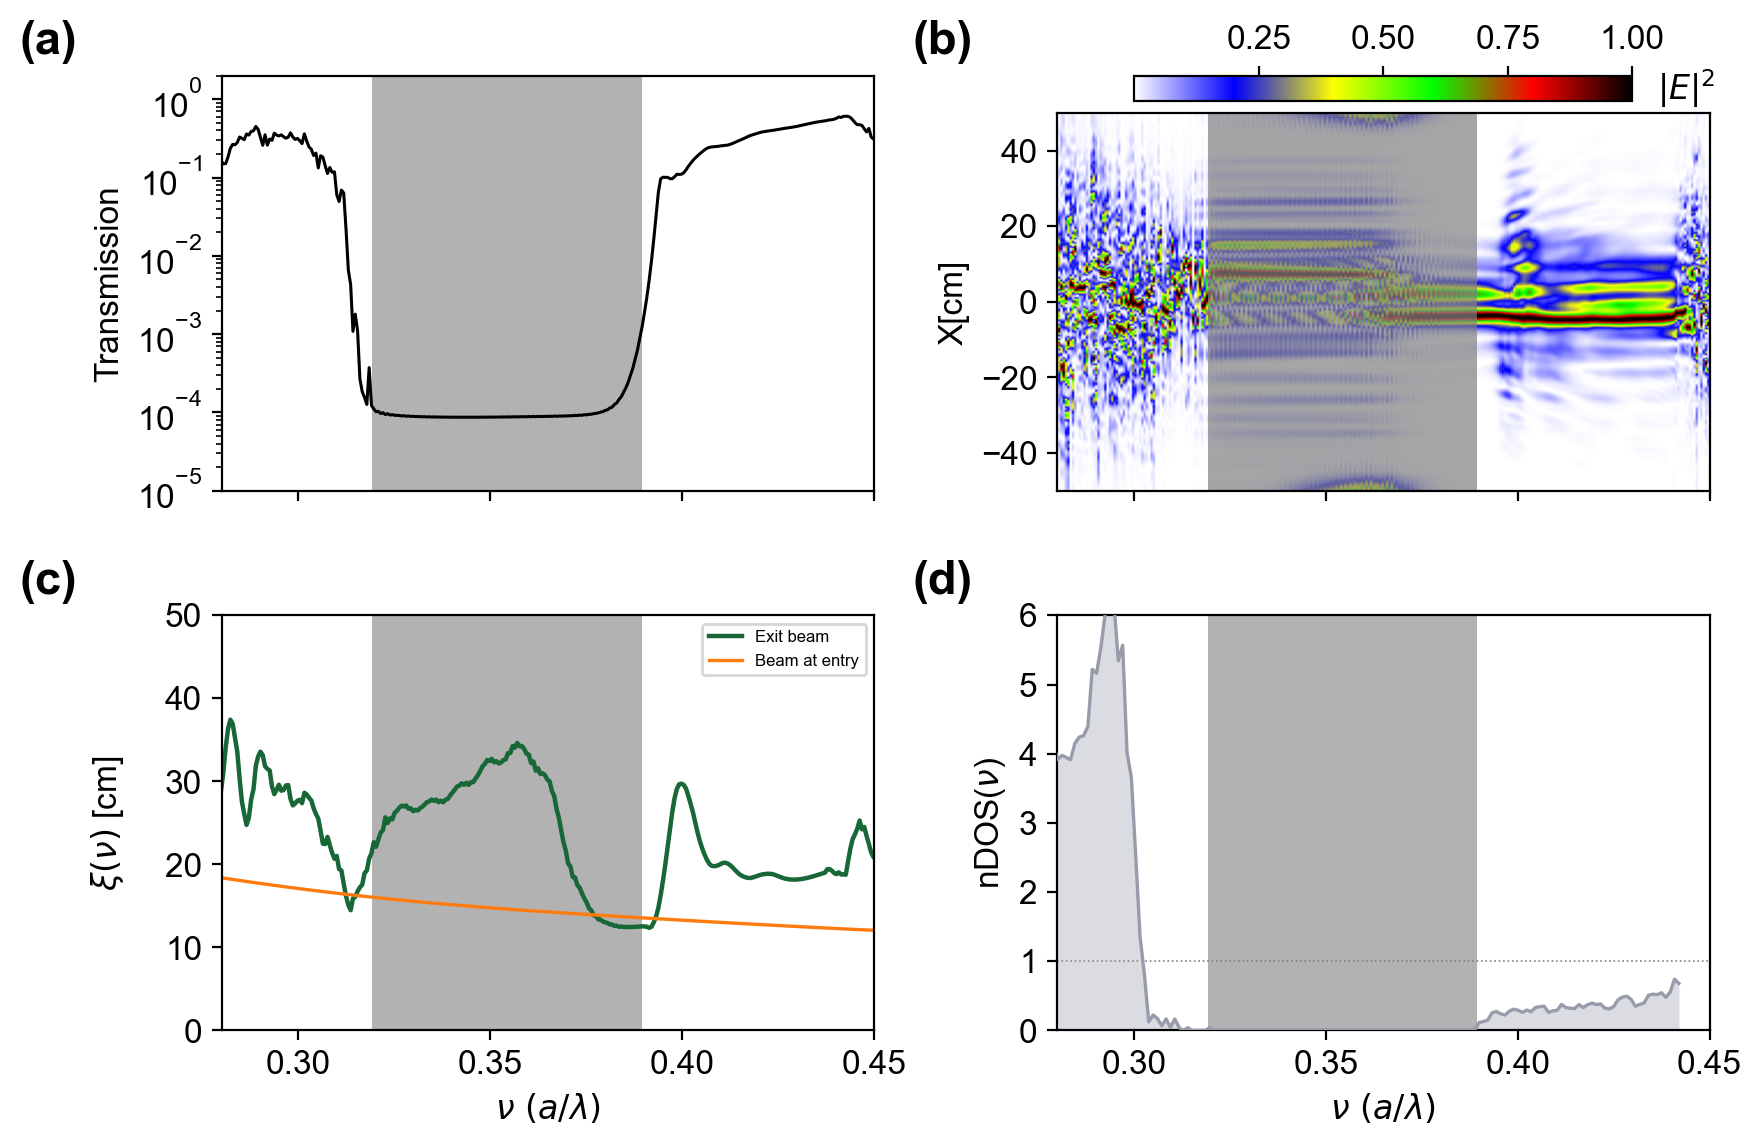

In [12]:
# 2x2 gap diagnostic: (a) transmission / (b) intensity map / (c) PR / (d) nDOS,
# every panel against a/lambda.
# The gap (grey) lands on the -40 dB transmission floor, the dark map stripe and
# the nDOS zero -> the intensity "after ~0.40" is the upper pass-band, not in-gap
# leakage. The nDOS comes from the MPB band statistics of the SAME structure
# family (chi=0.37, eps=50; see "Luis Analysis/Computing_nDOS.ipynb"), so it is an
# independent confirmation of the gap edges used for the shading.
plot_gap_diagnostic(lines, freqs_list, lines_x,
                    xlim=(0.28, 0.45),  gaps=((0.162002, 0.267659), (0.3193,0.3894)),#Values obtained from Luis Analysis folder
                    dataset_index=0, title="", threshold=0,logplot=False)
# core-window version (drops the transverse domain-edge background in the gap):
# plot_gap_diagnostic(lines, freqs_list, lines_x, core_x=25*1.5873, title="0 mm gap cavity (core |x|<25a)")
# without panel (d):  plot_gap_diagnostic(..., ndos_file=None)
